In [1]:
import pandas as pd
import re

## 1) Loading the data (we were assigned the synthetic dataset number 2)

In [2]:
data = pd.read_excel("syn2.xlsx")
var_desc = pd.read_excel("variables_description.xlsx")

In [3]:
print("Shape:", data.shape)
display(data.head())

Shape: (3961, 27)


,gender_0male_1female,age_YEARS,diabetes,hypertension,COPD,PVD,CKD,IHD,AF,VHD,...,GFR_discharge,WBC,sodium,RDW,platelets,bilirubin,potassium,length_of_stay_DAYS,time_discharge_to death_MONTHS,death
0,0,48.85803,0,0,0,0,0,0,0,0,...,80.768963,9.40,138.00,21.3,178.0,1.090,3.9,0.456785,5.000000,1
1,0,49.67481,0,0,0,0,0,0,0,0,...,54.435869,4.40,127.42,21.6,114.0,5.765,4.8,0.245513,0.700000,1
2,0,85.35892,0,0,0,0,0,0,0,0,...,48.993978,10.50,130.00,17.2,289.0,0.520,4.0,1.632458,8.033333,1
3,0,52.80388,0,0,0,0,0,0,0,0,...,75.232868,8.50,135.00,13.3,188.0,0.550,6.1,5.921769,0.033333,1
4,0,67.30150,0,0,0,0,0,0,0,0,...,31.042884,13.17,136.40,14.7,274.0,0.500,5.3,17.214475,20.433333,0


In [4]:
display(var_desc.head())

,variable,meaning,code
0,gender_0male_1female,gender,"0=male, 1=female"
1,age_YEARS,age (years),NaN
2,diabetes,history of diabetes,"0=no, 1=yes"
3,hypertension,history of hypertension,"0=no, 1=yes"
4,COPD,history of chronic obstructive pulmonary disease,"0=no, 1=yes"


## 2) Creating a description table for all covariates in the dataset

In [5]:
# removing a space in column name for consistency
data = data.rename(columns={
    "time_discharge_to death_MONTHS": "time_discharge_to_death_MONTHS"
})
var_desc["variable"] = var_desc["variable"].replace({
    "time_discharge_to death_MONTHS": "time_discharge_to_death_MONTHS"
})

In [6]:
def infer_variable_type(row):
    variable = row["variable"]
    code = row["code"]
    
    if variable == "death":
        return "Event indicator / Binary outcome"
    
    if variable == "time_discharge_to_death_MONTHS":
        return "Survival time"
    
    if pd.notna(code):
        code_str = str(code).lower()
        if "0=" in code_str and "1=" in code_str:
            return "Binary"
        else:
            return "Categorical"
    
    return "Continuous"

In [7]:
def extract_unit_from_meaning(meaning):
    """
    Extracts the text inside the last pair of parentheses.
    Example:
    'blood urea nitrogen on admission (mg/dL)' -> 'mg/dL'
    """
    if pd.isna(meaning):
        return "Not Applicable"
    
    meaning = str(meaning)
    matches = re.findall(r"\((.*?)\)", meaning)
    
    if matches:
        return matches[-1]
    else:
        return "Not Applicable"

In [8]:
var_desc["type"] = var_desc.apply(infer_variable_type, axis=1)
variable_info = {}

for _, row in var_desc.iterrows():
    variable = row["variable"]
    meaning = row["meaning"]
    code = row["code"]
    variable_type = row["type"]
    
    if pd.notna(code):
        coding = code
    else:
        coding = extract_unit_from_meaning(meaning)
    
    variable_info[variable] = {
        "meaning": meaning,
        "type": variable_type,
        "coding": coding
    }

In [9]:
def summarize_variable(df, col, variable_info):
    series = df[col]
    
    n_unique = series.nunique(dropna=True)
    
    info = variable_info.get(col, {})
    variable_type = info.get("type", "Unknown")
    
    # Default values
    possible_values_or_categories = "Not Applicable"
    range_text = "Not Applicable"
    numerical_summary = "Not Applicable"
    

    # Binary variables
    if variable_type in ["Binary", "Event indicator / Binary outcome"]:
        counts = series.value_counts(dropna=False).sort_index()
        possible_values_or_categories = ", ".join([str(v) for v in series.dropna().sort_values().unique()])
        
        numerical_summary = "; ".join(
            [f"{idx}: {count} ({100 * count / len(series):.1f}%)" for idx, count in counts.items()]
        )
    

    # Continuous or survival-time variables
    elif variable_type in ["Continuous", "Survival time"]:
        if pd.api.types.is_numeric_dtype(series):
            min_val = series.min()
            max_val = series.max()
            mean_val = series.mean()
            median_val = series.median()
            std_val = series.std()
            
            range_text = f"{min_val:.2f}–{max_val:.2f}"
            numerical_summary = (
                f"Mean = {mean_val:.2f}, median = {median_val:.2f}, "
                f"SD = {std_val:.2f}"
            )
    
    
    # Categorical / ordinal variables
    elif variable_type in ["Categorical", "Ordinal"]:
        possible_values_or_categories = ", ".join([str(v) for v in series.dropna().unique()])
        numerical_summary = "Not Applicable"
        range_text = "Not Applicable"
    
    
    # Unknown variables
    else:
        if pd.api.types.is_numeric_dtype(series):
            min_val = series.min()
            max_val = series.max()
            range_text = f"{min_val:.2f}–{max_val:.2f}"
            numerical_summary = f"Mean = {series.mean():.2f}, median = {series.median():.2f}"
        else:
            possible_values_or_categories = ", ".join([str(v) for v in series.dropna().unique()])
    
    return {
        "variable": col,
        "meaning": info.get("meaning", "Not provided"),
        "variable_type": variable_type,
        "coding": info.get("coding", "Not Applicable"),
        "pandas_dtype": str(series.dtype),
        "n_unique": n_unique,
        "possible_values_or_categories": possible_values_or_categories,
        "range": range_text,
        "summary": numerical_summary,
    }

In [10]:
summary_rows = []

for col in data.columns:
    summary_rows.append(summarize_variable(data, col, variable_info))

variable_summary = pd.DataFrame(summary_rows)

variable_summary = variable_summary[
    [
        "variable",
        "meaning",
        "variable_type",
        "coding",
        "pandas_dtype",
        "n_unique",
        "possible_values_or_categories",
        "range",
        "summary",

    ]
]

display(variable_summary)

,variable,meaning,variable_type,coding,pandas_dtype,n_unique,possible_values_or_categories,range,summary
0,gender_0male_1female,gender,Binary,"0=male, 1=female",int64,2,"0, 1",Not Applicable,0: 2119 (53.5%); 1: 1842 (46.5%)
1,age_YEARS,age (years),Continuous,years,float64,3939,Not Applicable,18.35–99.82,"Mean = 74.26, median = 76.18, SD = 12.21"
2,diabetes,history of diabetes,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 1814 (45.8%); 1: 2147 (54.2%)
3,hypertension,history of hypertension,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 529 (13.4%); 1: 3432 (86.6%)
4,COPD,history of chronic obstructive pulmonary disease,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 3556 (89.8%); 1: 405 (10.2%)
5,PVD,history of peripheral vascular disease,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 3594 (90.7%); 1: 367 (9.3%)
6,CKD,history of chronic kidney disease,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 3156 (79.7%); 1: 805 (20.3%)
7,IHD,history of ischemic heart disease,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 1477 (37.3%); 1: 2484 (62.7%)
8,AF,history of atrial fibrilation,Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 2353 (59.4%); 1: 1608 (40.6%)
9,VHD,history of valvular heart disease),Binary,"0=no, 1=yes",int64,2,"0, 1",Not Applicable,0: 2980 (75.2%); 1: 981 (24.8%)


## 3) Missing Values Management

In [11]:
outcome_vars = ["time_discharge_to_death_MONTHS", "death"]

covariates = [
    col for col in data.columns
    if col not in outcome_vars
]

In [12]:
missing_summary = pd.DataFrame({
    "variable": covariates,
    "meaning": [variable_info.get(col, {}).get("meaning", "Not provided") for col in covariates],
    "variable_type": [variable_info.get(col, {}).get("type", "Unknown") for col in covariates],
    "missing_n": [data[col].isna().sum() for col in covariates],
    "missing_percent": [(data[col].isna().sum() / len(data) * 100) for col in covariates]
})

missing_summary["missing_percent"] = missing_summary["missing_percent"].round(2)

missing_summary_with_missing = missing_summary[
    missing_summary["missing_n"] > 0
]

if missing_summary_with_missing.empty:
    print("No missing values were found in the covariates.")
else:
    print("Missing values were found in the following covariates:")
    display(missing_summary_with_missing)

Missing values were found in the following covariates:


,variable,meaning,variable_type,missing_n,missing_percent
11,BNP,B-type natriuretic peptide on admission,Continuous,1858,46.91
13,BUN_discharge,blood urea nitrogen on discharge (mg/dL),Continuous,566,14.29
15,creatinine_discharge,creatinine on discharge (mg/dL),Continuous,572,14.44
16,GFR_admission,glomerular filtration rate on admission (mL/mi...,Continuous,110,2.78
17,GFR_discharge,glomerular filtration rate on discharge (mL/mi...,Continuous,134,3.38
18,WBC,white blood cells,Continuous,54,1.36
19,sodium,sodium (mEq/L),Continuous,38,0.96
20,RDW,red blood cell distribution width,Continuous,792,19.99
21,platelets,platelet count (1000/µL),Continuous,259,6.54
22,bilirubin,bilirubin (mg/dL),Continuous,1261,31.84


In [13]:
continuous_covariates = [
    col for col in covariates
    if variable_info.get(col, {}).get("type") == "Continuous"
]

categorical_covariates = [
    col for col in covariates
    if variable_info.get(col, {}).get("type") in ["Binary", "Categorical", "Ordinal"]
]

print("Continuous covariates:")
print(continuous_covariates)

print("\nCategorical / binary covariates:")
print(categorical_covariates)

Continuous covariates:
['age_YEARS', 'BNP', 'BUN_admission', 'BUN_discharge', 'creatinine_admission', 'creatinine_discharge', 'GFR_admission', 'GFR_discharge', 'WBC', 'sodium', 'RDW', 'platelets', 'bilirubin', 'potassium', 'length_of_stay_DAYS']

Categorical / binary covariates:
['gender_0male_1female', 'diabetes', 'hypertension', 'COPD', 'PVD', 'CKD', 'IHD', 'AF', 'VHD', 'PHTN']


In [14]:
data_imputed = data.copy()

In [15]:
for col in continuous_covariates:
    median_value = data_imputed[col].median()
    data_imputed[col] = data_imputed[col].fillna(median_value)

for col in categorical_covariates:
    mode_value = data_imputed[col].mode(dropna=True)[0]
    data_imputed[col] = data_imputed[col].fillna(mode_value)

In [16]:
imputation_summary = []

for col in continuous_covariates:
    imputation_summary.append({
        "variable": col,
        "meaning": variable_info.get(col, {}).get("meaning", "Not provided"),
        "variable_type": variable_info.get(col, {}).get("type", "Unknown"),
        "imputation_method": "Median",
        "imputation_value": data[col].median()
    })

for col in categorical_covariates:
    imputation_summary.append({
        "variable": col,
        "meaning": variable_info.get(col, {}).get("meaning", "Not provided"),
        "variable_type": variable_info.get(col, {}).get("type", "Unknown"),
        "imputation_method": "Mode",
        "imputation_value": data[col].mode(dropna=True)[0]
    })

imputation_summary = pd.DataFrame(imputation_summary)

display(imputation_summary)

,variable,meaning,variable_type,imputation_method,imputation_value
0,age_YEARS,age (years),Continuous,Median,76.182720
1,BNP,B-type natriuretic peptide on admission,Continuous,Median,778.100000
2,BUN_admission,blood urea nitrogen on admission (mg/dL),Continuous,Median,25.000000
3,BUN_discharge,blood urea nitrogen on discharge (mg/dL),Continuous,Median,28.000000
4,creatinine_admission,creatinine on admission (mg/dL),Continuous,Median,1.230000
5,creatinine_discharge,creatinine on discharge (mg/dL),Continuous,Median,1.230000
6,GFR_admission,glomerular filtration rate on admission (mL/mi...,Continuous,Median,49.837689
7,GFR_discharge,glomerular filtration rate on discharge (mL/mi...,Continuous,Median,50.433085
8,WBC,white blood cells,Continuous,Median,8.920000
9,sodium,sodium (mEq/L),Continuous,Median,138.000000


## 4) Defining Censored Observations

In [17]:
time_col = "time_discharge_to_death_MONTHS"
event_col = "death"

print("Survival time column:", time_col)
print("Event indicator column:", event_col)

print("\nEvent indicator coding:")
print(variable_info[event_col]["coding"])

Survival time column: time_discharge_to_death_MONTHS
Event indicator column: death

Event indicator coding:
0=no, 1=yes


In [18]:
n_total = len(data_imputed)

n_events = (data_imputed[event_col] == 1).sum()
n_censored = (data_imputed[event_col] == 0).sum()

percent_events = 100 * n_events / n_total
percent_censored = 100 * n_censored / n_total

print(f"Total observations: {n_total}")
print(f"Observed deaths/events: {n_events} ({percent_events:.2f}%)")
print(f"Censored observations: {n_censored} ({percent_censored:.2f}%)")

Total observations: 3961
Observed deaths/events: 1679 (42.39%)
Censored observations: 2282 (57.61%)


In [19]:
data_imputed["survival_status"] = data_imputed[event_col].map({
    1: "Event: death observed within follow-up",
    0: "Censored: no death observed within follow-up"
})

display(data_imputed[[time_col, event_col, "survival_status"]].head())

,time_discharge_to_death_MONTHS,death,survival_status
0,5.000000,1,Event: death observed within follow-up
1,0.700000,1,Event: death observed within follow-up
2,8.033333,1,Event: death observed within follow-up
3,0.033333,1,Event: death observed within follow-up
4,20.433333,0,Censored: no death observed within follow-up


The survival time variable is time_discharge_to_death_MONTHS, defined as the time from hospital discharge until death or the end of follow-up, measured in months. The event indicator is death, where death = 1 indicates that death was observed within three years of discharge, and death = 0 indicates that death was not observed during the follow-up period. Observations with death = 0 are therefore treated as right-censored, meaning that the patient was still alive at the end of follow-up or that death was not observed within the study window.

## 5) Sample Size and Censoring Summary

In [20]:
n_total = len(data_imputed)

n_events = (data_imputed[event_col] == 1).sum()
n_censored = (data_imputed[event_col] == 0).sum()

percent_events = 100 * n_events / n_total
percent_censored = 100 * n_censored / n_total

sample_censoring_summary = pd.DataFrame({
    "measure": [
        "Sample size",
        "Observed events (death = 1)",
        "Censored observations (death = 0)"
    ],
    "n": [
        n_total,
        n_events,
        n_censored
    ],
    "percent": [
        100.00,
        round(percent_events, 2),
        round(percent_censored, 2)
    ]
})

print(f"Sample size: {n_total}")
print(f"Censored observations: {n_censored} ({percent_censored:.2f}%)")
print(f"Observed events: {n_events} ({percent_events:.2f}%)")

Sample size: 3961
Censored observations: 2282 (57.61%)
Observed events: 1679 (42.39%)


## 7) Observed Time

In [53]:
# time values summary
data_imputed['time_discharge_to_death_MONTHS'].describe().to_frame().to_csv("time_values_summary.csv", index=True)

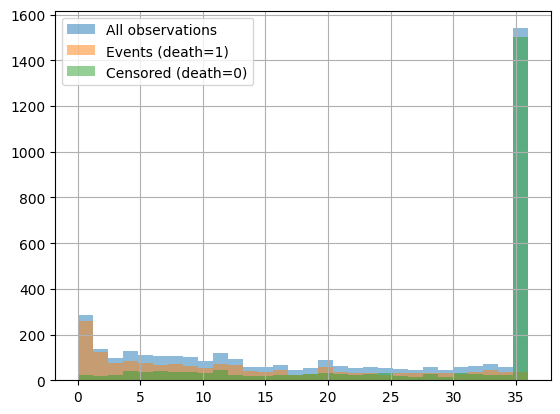

In [22]:
import matplotlib.pyplot as plt

# times histogram (total, and by event)
data_imputed['time_discharge_to_death_MONTHS'].hist(bins=30, alpha=0.5, label='All observations')
data_imputed[data_imputed[event_col] == 1]['time_discharge_to_death_MONTHS'].hist(bins=30, alpha=0.5, label='Events (death=1)')
data_imputed[data_imputed[event_col] == 0]['time_discharge_to_death_MONTHS'].hist(bins=30, alpha=0.5, label='Censored (death=0)')
plt.legend()

The distribution of the times is, as expected, right-skewed, because almost all the censored units are with time of 36 (censorship due to end of followup). There is also a bit more observation with a short time, which are almost entirely due to early deatch after hospital discharge.

## 8) Kaplan-Meier Survival Curve

<Axes: xlabel='timeline'>

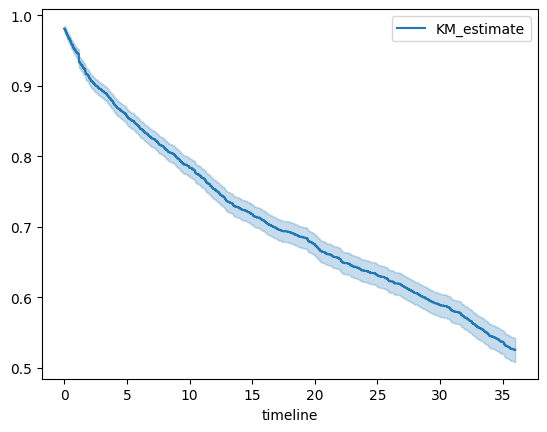

In [23]:
from lifelines import KaplanMeierFitter

km = KaplanMeierFitter()
km.fit(durations=data_imputed[time_col], event_observed=data_imputed[event_col])
km.plot_survival_function()

The survival function plot shows a steady decline from 1 to 0.5 across the follow-up time, ending at 36. The decline is a bit more steep in the beginning, corresponding to the high number of early deaths we identified in the previous section. After that, the decline is more gradual, with a more or less constant linear slope, which is consistent with the right-skewed distribution of the times we observed in the histogram. The survival function ends at around 0.5, which means that about half of the patients are expected to survive beyond 36 months after hospital discharge. (???)

## 9) Stratified Kaplan-Meier Curves

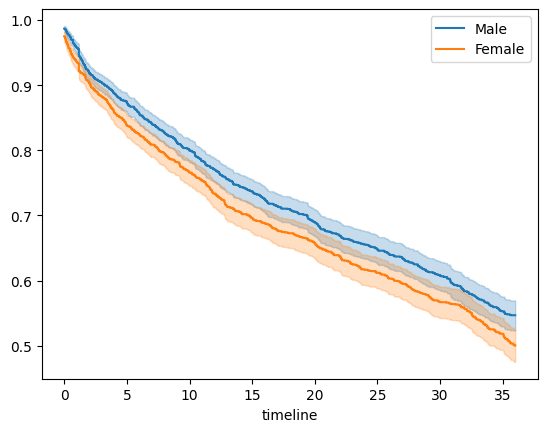

In [24]:
# we will stratify by gender and diabetes

male_data = data_imputed[data_imputed["gender_0male_1female"] == 0]
female_data = data_imputed[data_imputed["gender_0male_1female"] == 1]

male_km = KaplanMeierFitter().fit(durations=male_data[time_col], event_observed=male_data[event_col])
female_km = KaplanMeierFitter().fit(durations=female_data[time_col], event_observed=female_data[event_col])

male_km.plot_survival_function(label="Male")
female_km.plot_survival_function(label="Female")
plt.legend()

The plot shows that male have a slightly higher survival probability, altought the CIs overlap across the entire follow-up period, so we cannot conclude that there is a significant difference in survival between the two groups. The plot also shows that the survival probability for both groups declines similarly over time, which means that the differece in survival between the two groups is consistent across the follow-up period.

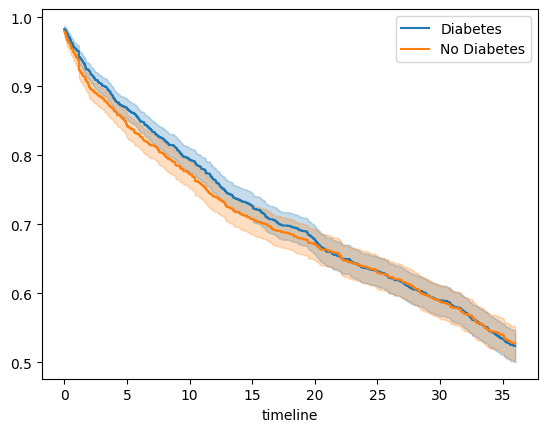

In [25]:
diabetes_data = data_imputed[data_imputed["diabetes"] == 1]
no_diabetes_data = data_imputed[data_imputed["diabetes"] == 0]

diabetes_km = KaplanMeierFitter().fit(durations=diabetes_data[time_col], event_observed=diabetes_data[event_col])
no_diabetes_km = KaplanMeierFitter().fit(durations=no_diabetes_data[time_col], event_observed=no_diabetes_data[event_col])

diabetes_km.plot_survival_function(label="Diabetes")
no_diabetes_km.plot_survival_function(label="No Diabetes")
plt.legend()

The plot shows that while the survival probability of the diabetes group is slightly higher than those with no diabeters at the beginning of the follow-up period, it converges about half-way through, and in no point the CIs do not overlap, so we cannot conclude that there is a significant difference in survival between the two groups.

## 11) Cox Proportional Model

In [28]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(data_imputed.drop(columns=["survival_status"]), duration_col=time_col, event_col="death")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 3961 total observations, 2282 right-censored observations>
             duration col = 'time_discharge_to_death_MONTHS'
                event col = 'death'
      baseline estimation = breslow
   number of observations = 3961
number of events observed = 1679
   partial log-likelihood = -12892.08
         time fit was run = 2026-06-10 17:31:14 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
gender_0male_1female -0.03      0.97      0.06           -0.14            0.08                0.87                1.08
age_YEARS             0.04      1.04      0.00            0.04            0.05                1.04                1.05
diabetes             -0.00      1.00      0.05           -0.11            0.10                0.90                1.11
hypertension         -0.04      0.96      0.08           -0.21            0.12                0.81                1.13
COPD                  0.19      1.21      0.08            0.03            0.35                1.03                1.41
PVD                   0.11      1.12      0.10           -0.09            0.31                0.91                1.36
CKD                   0.05      1.05      0.08           -0.11            0.21                0.89                1.23
IHD                  -0.05      0.95      0.05           -0.15            0.06                0.86                1.06
AF                    0.07      1.08      0.05           -0.03            0.18                0.97                1.19
VHD                  -0.05      0.95      0.06           -0.17            0.07                0.84                1.07
PHTN                  0.07      1.07      0.07           -0.06            0.20                0.94                1.22
BNP                   0.00      1.00      0.00            0.00            0.00                1.00                1.00
BUN_admission         0.01      1.01      0.00            0.01            0.02                1.01                1.02
BUN_discharge         0.01      1.01      0.00            0.01            0.01                1.01                1.01
creatinine_admission -0.06      0.94      0.06           -0.17            0.05                0.84                1.05
creatinine_discharge -0.02      0.98      0.06           -0.14            0.10                0.87                1.11
GFR_admission        -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
GFR_discharge         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
WBC                   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
sodium               -0.03      0.97      0.01           -0.04           -0.02                0.96                0.98
RDW                   0.11      1.12      0.01            0.08            0.14                1.09                1.15
platelets             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
bilirubin             0.11      1.12      0.06            0.00            0.22                1.00                1.25
potassium            -0.09      0.92      0.04           -0.17           -0.00                0.84                1.00
length_of_stay_DAYS   0.01      1.01      0.00            0.00            0.02                1.00                1.02

                      cmp to     z      p  -log2(p)
covariate                                          
gender_0male_1female    0.00 -0.53   0.60      0.74
age_YEARS               0.00 14.91 <0.005    164.64
diabetes                0.00 -0.06   0.95      0.08
hypertension            0.00 -0.54   0.59      0.76
COPD                    0.00  2.36   0.02      5.76
PVD                     0.00  1.0

In [49]:
cph.summary.sort_values("p")[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(4)

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_YEARS,1.0434,1.0376,1.0492,0.0000
RDW,1.1185,1.0880,1.1497,0.0000
sodium,0.9718,0.9616,0.9821,0.0000
BUN_discharge,1.0104,1.0065,1.0144,0.0000
BNP,1.0002,1.0001,1.0002,0.0000
BUN_admission,1.0110,1.0064,1.0155,0.0000
length_of_stay_DAYS,1.0103,1.0044,1.0162,0.0006
COPD,1.2077,1.0323,1.4130,0.0184
bilirubin,1.1192,1.0036,1.2480,0.0428
